In [2]:
import os
import json
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
import numpy as np
import pandas as pd

def read_json(path):
    with open(path, 'r', encoding="utf-8") as f:
        data = json.load(f)
    return data

def write_json(data, path):
    if not os.path.exists(os.path.dirname(path)):
        os.makedirs(os.path.dirname(path))
    with open(path, 'w', encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)
        

In [3]:
#fewrel_t5 results-si
experiments = {'run_1':'',
               'run_2': '/Users/sefika/phd_projects/revision/CRE_PTM/results/t5/FewRel/model2/forgetting_matrix.json' ,
               'run_3': '/Users/sefika/phd_projects/revision/CRE_PTM/results/t5/FewRel/model3/forgetting_matrix.json',
               'run_4': '/Users/sefika/phd_projects/revision/CRE_PTM/results/t5/FewRel/model4/forgetting_matrix.json',
               'run_5': '/Users/sefika/phd_projects/revision/CRE_PTM/results/t5/FewRel/model5/forgetting_matrix.json'}

In [4]:
data1 = read_json(experiments['run_1'])
data2 = read_json(experiments['run_2'])
data3 = read_json(experiments['run_3'])
data4 = read_json(experiments['run_4'])
data5 = read_json(experiments['run_5'])

In [10]:
data1 = pd.DataFrame(data1)
data2 = pd.DataFrame(data2)
data3 = pd.DataFrame(data3)
data4 = pd.DataFrame(data4)
data5 = pd.DataFrame(data5)


In [11]:
combined = pd.concat([data1, data2, data3, data4, data5])

# Compute average accuracy
average_accuracy = (
    combined
    .groupby(['base_task', 'task'], as_index=False)
    .agg({'accuracy': 'mean'})
)

# Optional: Pivot into matrix form
accuracy_matrix = average_accuracy.pivot(index='base_task', columns='task', values='accuracy')


In [12]:
accuracy_matrix

task,1,2,3,4,5,6,7,8,9,10
base_task,,,,,,,,,,
1,0.970357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.936607,0.952321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.925536,0.951429,0.959643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.894821,0.922857,0.954821,0.962321,NaN,NaN,NaN,NaN,NaN,NaN
5,0.881786,0.917321,0.946071,0.943929,0.960714,NaN,NaN,NaN,NaN,NaN
6,0.865000,0.915536,0.937500,0.936071,0.946607,0.950000,NaN,NaN,NaN,NaN
7,0.845714,0.882500,0.933929,0.907500,0.936607,0.941429,0.932500,NaN,NaN,NaN
8,0.851786,0.897679,0.930714,0.901071,0.930357,0.936786,0.925000,0.956964,NaN,NaN
9,0.822321,0.886607,0.929821,0.880000,0.920893,0.934286,0.915714,0.944643,0.931607,NaN


In [17]:
accuracy_matrix.to_json('fewre_t5_accuracy_matrix.json', orient='split', indent=4, )


In [19]:
accuracy_matrix ={
  "1": {"1": 0.970357, "2": np.NaN, "3": np.NaN, "4": np.NaN, "5": np.NaN, "6": np.NaN, "7": np.NaN, "8": np.NaN, "9": np.NaN, "10": np.NaN},
  "2": {"1": 0.936607, "2": 0.952321, "3": np.NaN, "4": np.NaN, "5": np.NaN, "6": np.NaN, "7": np.NaN, "8": np.NaN, "9": np.NaN, "10": np.NaN},
  "3": {"1": 0.925536, "2": 0.951429, "3": 0.959643, "4": np.NaN, "5": np.NaN, "6": np.NaN, "7": np.NaN, "8": np.NaN, "9": np.NaN, "10": np.NaN},
  "4": {"1": 0.894821, "2": 0.922857, "3": 0.954821, "4": 0.962321, "5": np.NaN, "6": np.NaN, "7": np.NaN, "8": np.NaN, "9": np.NaN, "10": np.NaN},
  "5": {"1": 0.881786, "2": 0.917321, "3": 0.946071, "4": 0.943929, "5": 0.960714, "6": np.NaN, "7": np.NaN, "8": np.NaN, "9": np.NaN, "10": np.NaN},
  "6": {"1": 0.865, "2": 0.915536, "3": 0.9375, "4": 0.936071, "5": 0.946607, "6": 0.95, "7": np.NaN, "8": np.NaN, "9": np.NaN, "10": np.NaN},
  "7": {"1": 0.845714, "2": 0.8825, "3": 0.933929, "4": 0.9075, "5": 0.936607, "6": 0.941429, "7": 0.9325, "8": np.NaN, "9": np.NaN, "10": np.NaN},
  "8": {"1": 0.851786, "2": 0.897679, "3": 0.930714, "4": 0.901071, "5": 0.930357, "6": 0.936786, "7": 0.925, "8": 0.956964, "9": np.NaN, "10": np.NaN},
  "9": {"1": 0.822321, "2": 0.886607, "3": 0.929821, "4": 0.88, "5": 0.920893, "6": 0.934286, "7": 0.915714, "8": 0.944643, "9": 0.931607, "10": np.NaN},
  "10": {"1": 0.7925, "2": 0.867321, "3": 0.917143, "4": 0.875536, "5": 0.906786, "6": 0.928571, "7": 0.879464, "8": 0.944464, "9": 0.940893, "10": 0.908036}
}


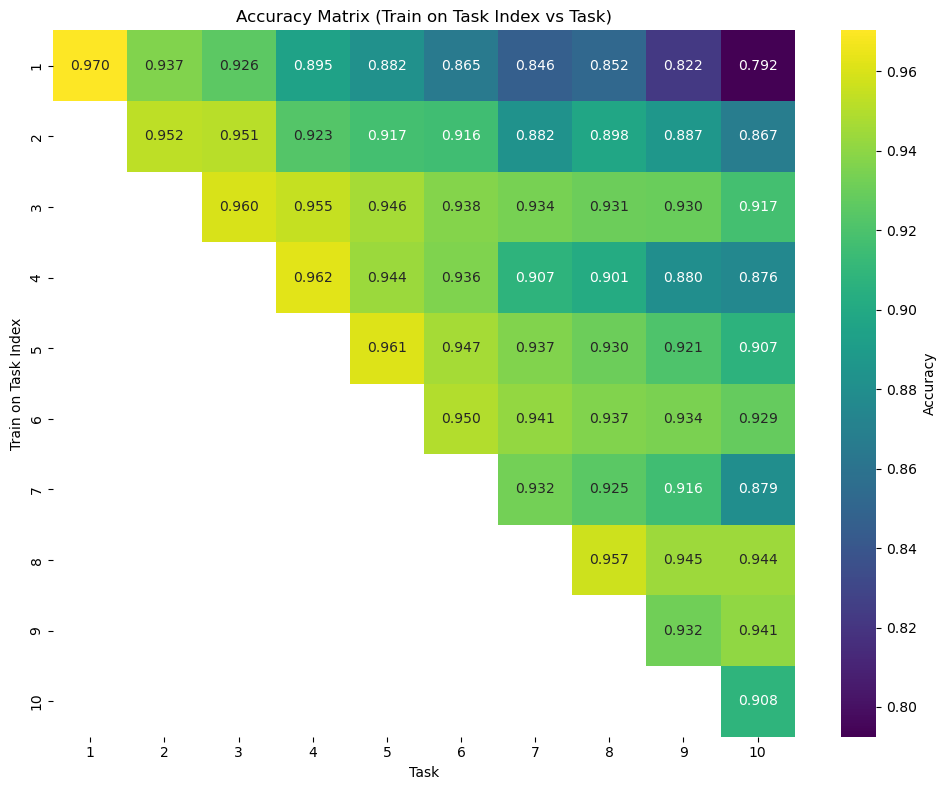

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data


# Create DataFrame
df =  pd.DataFrame(accuracy_matrix)
# Update the y-axis label
plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True, fmt=".3f", cmap="viridis", cbar_kws={"label": "Accuracy"})
plt.title("Accuracy Matrix (Train on Task Index vs Task)")
plt.xlabel("Task")
plt.ylabel("Train on Task Index")
plt.tight_layout()
plt.show()


In [3]:
#tacred_t5 results
experiments = {'run_1':'/Users/sefika/phd_projects/CRE_PTM copy/src/test/results_memory_cl_tacred/memory_experiments/m10/model1/forgetting_matrix.json',
               'run_2': '/Users/sefika/phd_projects/CRE_PTM copy/src/test/results_memory_cl_tacred/memory_experiments/m10/model2/forgetting_matrix.json' ,
               'run_3': '/Users/sefika/phd_projects/CRE_PTM copy/src/test/results_memory_cl_tacred/memory_experiments/m10/model3/forgetting_matrix.json',
               'run_4': '/Users/sefika/phd_projects/CRE_PTM copy/src/test/results_memory_cl_tacred/memory_experiments/m10/model4/forgetting_matrix.json',
               'run_5': '/Users/sefika/phd_projects/CRE_PTM copy/src/test/results_memory_cl_tacred/memory_experiments/m10/model5/forgetting_matrix.json'}

In [4]:
data1 = read_json(experiments['run_1'])
data2 = read_json(experiments['run_2'])
data3 = read_json(experiments['run_3'])
data4 = read_json(experiments['run_4'])
data5 = read_json(experiments['run_5'])

In [5]:
data1 = pd.DataFrame(data1)
data2 = pd.DataFrame(data2)
data3 = pd.DataFrame(data3)
data4 = pd.DataFrame(data4)
data5 = pd.DataFrame(data5)


In [6]:
combined = pd.concat([data1, data2, data3, data4, data5])

# Compute average accuracy
average_accuracy = (
    combined
    .groupby(['base_task', 'task'], as_index=False)
    .agg({'accuracy': 'mean'})
)

# Optional: Pivot into matrix form
accuracy_matrix = average_accuracy.pivot(index='base_task', columns='task', values='accuracy')


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data


# Create DataFrame
df =  pd.DataFrame(accuracy_matrix)
df.at[1, 1] = 0.9610
df_percent = df * 100  # Convert to percentage
# Update the y-axis label
# Save the heatmap with updated font sizes as a high-resolution PNG
plt.figure(figsize=(14, 12))
ax = sns.heatmap(
    df_percent,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    cbar_kws={"label": "Accuracy (%)"},
    annot_kws={"size": 16, "weight": "bold"},
    linewidths=0.5,
    square=True
)

plt.title("Accuracy Matrix (Train on Task Index vs Task) on TACRED with Flan T5 Base", fontsize=20, weight="bold")
plt.xlabel("Task", fontsize=20, weight="bold")
plt.ylabel("Train on Task Index", fontsize=20, weight="bold")
plt.xticks(fontsize=16, weight="bold")
plt.yticks(fontsize=16, weight="bold")

# Adjust colorbar font
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)
cbar.set_label("Accuracy (%)", fontsize=20, weight="bold")

# Save the figure
file_path = "accuracy_matrix_percent_t5_tacred.png"
eps_path = "accuracy_matrix_percent_t5_tacred.eps"
plt.tight_layout()
plt.savefig(file_path, dpi=350)
plt.savefig(eps_path, format='eps')
plt.close()




